# Week 3: Python & Data Wrangling

### Objectives
- Learn Python basics for data analysis
- Read and manipulate CSV files using Pandas
- Clean a messy dataset
- Handle missing values
- Filter rows
- Create new columns
- Visualize data using Matplotlib and Seaborn

**Dataset:** Workout Dataset (Duration, Date, Pulse, Maxpulse, Calories)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the Dataset

In this step, we import the CSV dataset into a Pandas DataFrame.

In [7]:
df = pd.read_csv("data.csv")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


# Step 2: Explore the Dataset

Check the structure, data types, and dimensions of the dataset.

In [8]:
df.shape

(32, 5)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


In [10]:
df.describe()

,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


# Step 3: Identify Missing Values

Before cleaning the dataset, check for missing values.

In [11]:
df.isnull().sum()

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

# Step 4: Handle Missing Values

Replace missing values in the Calories column with the average calories.

In [12]:
df["Calories"] = df["Calories"].fillna(df["Calories"].mean())

df.isnull().sum()

Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    0
dtype: int64

In [14]:
# Remove rows with missing Date values
df.dropna(subset=["Date"], inplace=True)

# Verify missing values
df.isnull().sum()

Duration    0
Date        0
Pulse       0
Maxpulse    0
Calories    0
dtype: int64

# Step 5: Remove Duplicate Records

Duplicate records can affect analysis. Remove them.

In [15]:
df.drop_duplicates(inplace=True)

df.shape

(30, 5)

# Step 6: Filter the Dataset

Display workout sessions where Pulse is greater than 110.

In [16]:
high_pulse = df[df["Pulse"] > 110]

high_pulse.head()

,Duration,Date,Pulse,Maxpulse,Calories
1,60,'2020/12/02',117,145,479.0
4,45,'2020/12/05',117,148,406.0
23,60,'2020/12/23',130,101,300.0


# Step 7: Create a New Column

Create an Intensity column based on Pulse values.

In [17]:
df["Intensity"] = df["Pulse"].apply(
    lambda x: "High" if x > 120 else "Normal"
)

df.head()

,Duration,Date,Pulse,Maxpulse,Calories,Intensity
0,60,'2020/12/01',110,130,409.1,Normal
1,60,'2020/12/02',117,145,479.0,Normal
2,60,'2020/12/03',103,135,340.0,Normal
3,45,'2020/12/04',109,175,282.4,Normal
4,45,'2020/12/05',117,148,406.0,Normal


# Step 8: Statistical Summary

In [18]:
print("Average Calories:", df["Calories"].mean())
print("Average Pulse:", df["Pulse"].mean())
print("Maximum Calories:", df["Calories"].max())
print("Minimum Calories:", df["Calories"].min())

Average Calories: 307.2353333333333
Average Pulse: 103.73333333333333
Maximum Calories: 479.0
Minimum Calories: 195.1


# Step 9: Line Plot

Visualize the relationship between Duration and Calories.

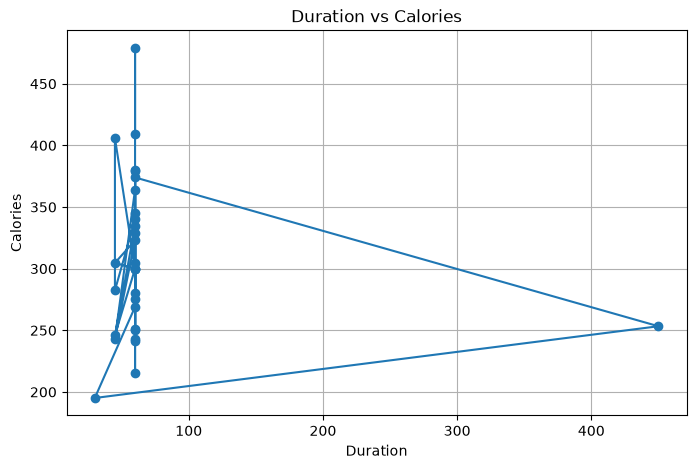

In [19]:
plt.figure(figsize=(8,5))
plt.plot(df["Duration"], df["Calories"], marker="o")
plt.title("Duration vs Calories")
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

# Step 10: Scatter Plot

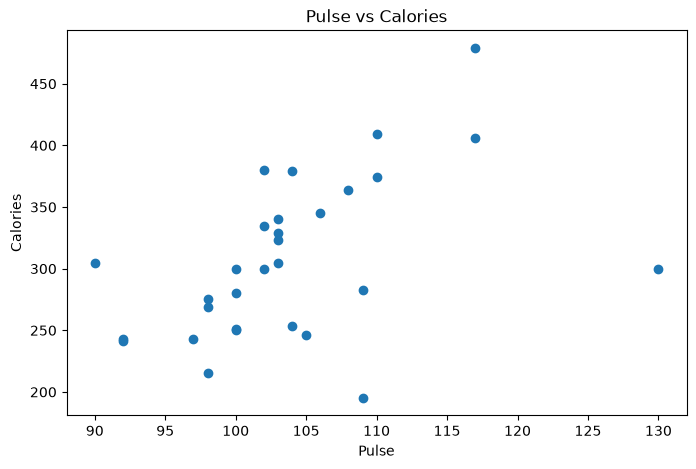

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["Pulse"], df["Calories"])
plt.title("Pulse vs Calories")
plt.xlabel("Pulse")
plt.ylabel("Calories")
plt.show()

# Step 11: Histogram

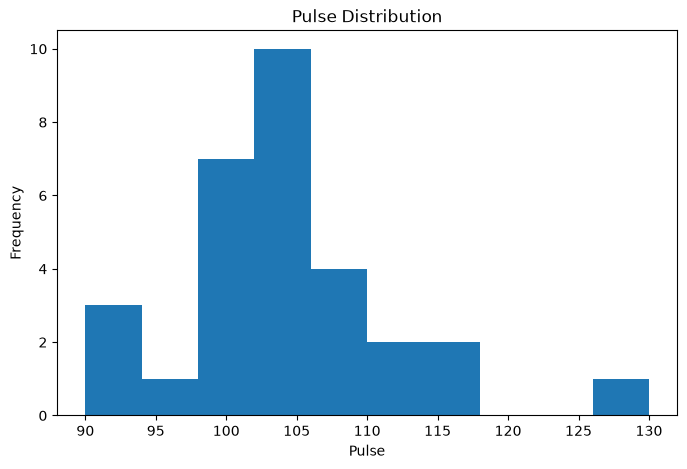

In [21]:
plt.figure(figsize=(8,5))
plt.hist(df["Pulse"], bins=10)
plt.title("Pulse Distribution")
plt.xlabel("Pulse")
plt.ylabel("Frequency")
plt.show()

# Step 12: Correlation Heatmap

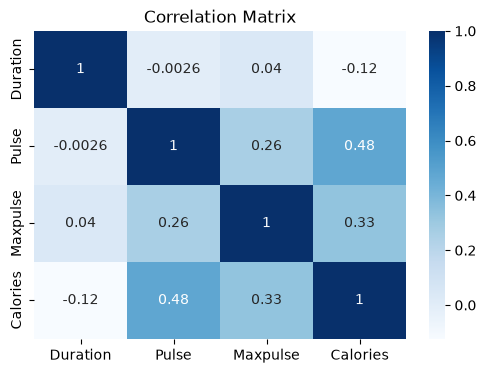

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

# Step 13: Save the Cleaned Dataset

In [23]:
df.to_csv("cleaned_data.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Conclusion

The dataset was successfully cleaned using Pandas.

Tasks completed:
- Loaded CSV dataset
- Explored dataset
- Handled missing values
- Removed duplicates
- Filtered rows
- Created a new column
- Performed statistical analysis
- Visualized data using Matplotlib and Seaborn
- Saved the cleaned dataset

This notebook demonstrates the basic concepts of Python and Data Wrangling using Pandas.